In [1]:
#### Import librairies
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sns

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/' # mag cut at 24.5
root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_2/'        # mag cut at 26.5

In [42]:
images = np.load(root_dir_v2+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v2+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v2+'img_data.csv')

In [43]:
images.shape

(10000, 59, 59, 6)

In [65]:
beta = 20
bands = [0,1,2,3,4,5]
max_i_noisy = []
I = []

for i in range (len(bands)):
    I.append(np.mean(np.max(images[:,:,:,i], axis = (1,2))))

In [66]:
I

[3.4725035028144715,
 4.712976415619254,
 7.635940959954262,
 11.900790692928434,
 13.827042811599373,
 13.843257184934616]

In [67]:
y = np.copy(images[:10])
test = np.zeros((10,59,59,6))

for i in range (10):
    for ib, b in enumerate(bands):
        test[i,:,:,b] = np.tanh(np.arcsinh(images[i,:,:,b]/(I[b]/beta)))

In [68]:
np.max(test)

0.994999904522812

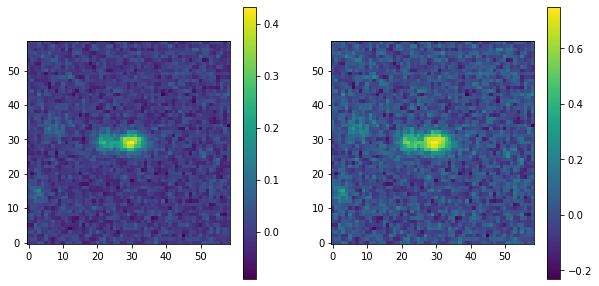

In [71]:
fig, axes = plt.subplots(1,2, figsize = (10,5))

fig_1 = axes[0].imshow(images[2,:,:,2], origin = 'lower')
fig_2 = axes[1].imshow(test[2,:,:,2], origin = 'lower')

fig.colorbar(fig_1 ,ax=axes[0])
fig.colorbar(fig_2 ,ax=axes[1])